In [ ]:
!pip install mealpy

In [ ]:
import numpy as np
from mealpy import PermutationVar, GA

# small example
# jobs_data = [
#     [(0, 3), (1, 2), (2, 2)],  # Job 0
#     [(0, 2), (2, 1), (1, 4)],  # Job 1
#     [(1, 4), (0, 1), (2, 3)]   # Job 2
# ]
# num_jobs = 3
# num_ops = 3
# num_machines = 3


# 1. Define the JSP Dataset (Fisher and Thompson 6x6 - FT06)
# optimal = 55
# Format: (machine_id, duration)
jobs_data = [
    [(2, 1), (0, 3), (1, 6), (3, 7), (5, 3), (4, 6)], # Job 0
    [(1, 8), (2, 5), (4, 10), (5, 10), (0, 10), (3, 4)], # Job 1
    [(2, 5), (3, 4), (5, 8), (0, 9), (1, 1), (4, 7)], # Job 2
    [(1, 5), (0, 5), (2, 5), (3, 3), (4, 8), (5, 9)], # Job 3
    [(2, 9), (1, 3), (4, 5), (5, 4), (0, 3), (3, 1)], # Job 4
    [(1, 3), (3, 3), (5, 9), (0, 10), (4, 4), (2, 1)]  # Job 5
]
num_jobs = 6
num_ops = 6
num_machines = 6



# Create our base sequence:
base_job_sequence = np.arange(num_jobs * num_ops)


def calculate_makespan(solution):
    machine_available_time = np.zeros(num_machines)
    job_available_time = np.zeros(num_jobs)
    job_op_current_index = np.zeros(num_jobs, dtype=int)

    for idx in solution:
        job_id = base_job_sequence[int(idx)] // num_ops
        op_index = job_op_current_index[job_id]
        machine_id, duration = jobs_data[job_id][op_index]
        # Start when both the job and the required machine are ready
        start_time = max(job_available_time[job_id], machine_available_time[machine_id])
        end_time = start_time + duration

        # # Update trackers
        job_available_time[job_id] = end_time
        machine_available_time[machine_id] = end_time
        job_op_current_index[job_id] += 1
    return np.max(machine_available_time)

# 3. Define the Problem Dictionary using PermutationVar
problem_dict = {
    "bounds": PermutationVar(valid_set=base_job_sequence),
    "obj_func": calculate_makespan,
    "minmax": "min",
}

In [ ]:
import matplotlib.pyplot as plt

def decode_schedule(solution):
    """
    Translates the raw GA permutation sequence into a detailed list
    of tasks containing exact start, end, and duration times.
    """
    machine_available_time = np.zeros(num_machines)
    job_available_time = np.zeros(num_jobs)
    job_op_current_index = np.zeros(num_jobs, dtype=int)

    schedule = [] # Will hold dictionaries of each operation

    for idx in solution:
        job_id = base_job_sequence[int(idx)] // num_ops
        op_index = job_op_current_index[job_id]
        machine_id, duration = jobs_data[job_id][op_index]

        # Start when both the job and the required machine are ready
        start_time = max(job_available_time[job_id], machine_available_time[machine_id])
        end_time = start_time + duration

        # Update trackers
        job_available_time[job_id] = end_time
        machine_available_time[machine_id] = end_time
        job_op_current_index[job_id] += 1

        # Append for plotting
        schedule.append({
            'Job': job_id,
            'Machine': machine_id,
            'Start': start_time,
            'Duration': duration
        })

    makespan = np.max(machine_available_time)
    return makespan, schedule

def plot_gantt_chart(schedule, makespan, num_machines, num_jobs):
    """
    Uses matplotlib to draw a visual Gantt chart of the optimal schedule.
    """
    fig, ax = plt.subplots(figsize=(12, 6))

    # Generate distinct colors for each job
    colors = plt.cm.tab10(np.linspace(0, 1, num_jobs))

    for task in schedule:
        job = task['Job']
        machine = task['Machine']
        start = task['Start']
        duration = task['Duration']

        # Plot the horizontal block
        ax.broken_barh([(start, duration)], (machine - 0.4, 0.8),
                       facecolors=colors[job], edgecolors='black', alpha=0.8)

        # Label the block
        ax.text(start + duration / 2, machine, f'J{job}',
                ha='center', va='center', color='white', weight='bold', fontsize=9)

    # Format Y-Axis (Machines)
    ax.set_ylim(-1, num_machines)
    ax.set_yticks(range(num_machines))
    ax.set_yticklabels([f'Machine {m}' for m in range(num_machines)])

    # Format X-Axis (Time)
    ax.set_xlabel('Time Units')
    ax.set_title(f'Monte Carlo: Absolute Best Operation Sequence Found\nMakespan: {makespan} time units', weight='bold')

    # Add a Legend outside the plot area
    legend_handles = [plt.Rectangle((0,0),1,1, color=colors[i], alpha=0.8) for i in range(num_jobs)]
    ax.legend(legend_handles, [f'Job {i}' for i in range(num_jobs)], bbox_to_anchor=(1.01, 1), loc='upper left')

    plt.grid(True, axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

In [ ]:
def run_monte_carlo(num_runs=10, epoch=300, pop_size=200):
    """
    Executes the GA multiple times to find the statistical distribution
    of the makespans and the absolute best sequence across all runs.
    """
    print(f"Starting Monte Carlo Simulation: {num_runs} independent runs...\n")

    makespans = []
    best_overall_solution = None
    best_overall_makespan = float('inf')
    for i in range(num_runs):
        # Initialize the GA model
        sd = np.random.default_rng(i)
        model = GA.BaseGA(epoch=epoch, pop_size=pop_size, pc=0.85, pm=0.2, seed = sd )
        best_agent = model.solve(problem_dict)

        # Extract results for this run
        current_makespan = best_agent.target.fitness
        makespans.append(current_makespan)

        # Track the absolute best result across all simulations
        if current_makespan < best_overall_makespan:
            best_overall_makespan = current_makespan
            best_overall_solution = best_agent.solution

        print(f"Run {i+1:02d}/{num_runs} | Makespan: {current_makespan}")

    # 5. Calculate and Output Statistics
    makespans = np.array(makespans)

    print("\n" + "="*50)
    print("MONTE CARLO SIMULATION RESULTS")
    print("="*50)
    print(f"Total Runs executed: {num_runs}")
    print(f"Mean Makespan:       {np.mean(makespans):.2f} time units")
    print(f"Std Deviation:       {np.std(makespans):.2f}")
    print(f"Worst Makespan:      {np.max(makespans)} time units")
    print(f"Best Makespan:       {best_overall_makespan} time units")
    print(f"Absolute Best Operation Sequence Found: \n{best_overall_solution}")
    print("="*50)
    _, final_schedule = decode_schedule(best_overall_solution)
    plot_gantt_chart(final_schedule, best_overall_makespan, num_machines, num_jobs)

    return makespans, best_overall_solution, best_overall_makespan

INFO:mealpy.evolutionary_based.GA.BaseGA:BaseGA(epoch=500, pop_size=100, pc=0.85, pm=0.1)
INFO:mealpy.evolutionary_based.GA.BaseGA:>>>Problem: P, Epoch: 1, Current best: 62.0, Global best: 62.0, Runtime: 0.03178 seconds
INFO:mealpy.evolutionary_based.GA.BaseGA:>>>Problem: P, Epoch: 2, Current best: 62.0, Global best: 62.0, Runtime: 0.02740 seconds
INFO:mealpy.evolutionary_based.GA.BaseGA:>>>Problem: P, Epoch: 3, Current best: 60.0, Global best: 60.0, Runtime: 0.02694 seconds
INFO:mealpy.evolutionary_based.GA.BaseGA:>>>Problem: P, Epoch: 4, Current best: 60.0, Global best: 60.0, Runtime: 0.02833 seconds
INFO:mealpy.evolutionary_based.GA.BaseGA:>>>Problem: P, Epoch: 5, Current best: 64.0, Global best: 60.0, Runtime: 0.02668 seconds
INFO:mealpy.evolutionary_based.GA.BaseGA:>>>Problem: P, Epoch: 6, Current best: 62.0, Global best: 60.0, Runtime: 0.02750 seconds


Starting Monte Carlo Simulation: 10 independent runs...



INFO:mealpy.evolutionary_based.GA.BaseGA:>>>Problem: P, Epoch: 7, Current best: 64.0, Global best: 60.0, Runtime: 0.03214 seconds
INFO:mealpy.evolutionary_based.GA.BaseGA:>>>Problem: P, Epoch: 8, Current best: 63.0, Global best: 60.0, Runtime: 0.03043 seconds
INFO:mealpy.evolutionary_based.GA.BaseGA:>>>Problem: P, Epoch: 9, Current best: 61.0, Global best: 60.0, Runtime: 0.03123 seconds
INFO:mealpy.evolutionary_based.GA.BaseGA:>>>Problem: P, Epoch: 10, Current best: 62.0, Global best: 60.0, Runtime: 0.03082 seconds
INFO:mealpy.evolutionary_based.GA.BaseGA:>>>Problem: P, Epoch: 11, Current best: 62.0, Global best: 60.0, Runtime: 0.03064 seconds
INFO:mealpy.evolutionary_based.GA.BaseGA:>>>Problem: P, Epoch: 12, Current best: 60.0, Global best: 60.0, Runtime: 0.03069 seconds
INFO:mealpy.evolutionary_based.GA.BaseGA:>>>Problem: P, Epoch: 13, Current best: 61.0, Global best: 60.0, Runtime: 0.03209 seconds
INFO:mealpy.evolutionary_based.GA.BaseGA:>>>Problem: P, Epoch: 14, Current best: 63.0,

Run 01/10 | Makespan: 58.0


INFO:mealpy.evolutionary_based.GA.BaseGA:>>>Problem: P, Epoch: 6, Current best: 63.0, Global best: 60.0, Runtime: 0.03128 seconds
INFO:mealpy.evolutionary_based.GA.BaseGA:>>>Problem: P, Epoch: 7, Current best: 66.0, Global best: 60.0, Runtime: 0.03518 seconds
INFO:mealpy.evolutionary_based.GA.BaseGA:>>>Problem: P, Epoch: 8, Current best: 64.0, Global best: 60.0, Runtime: 0.02883 seconds
INFO:mealpy.evolutionary_based.GA.BaseGA:>>>Problem: P, Epoch: 9, Current best: 62.0, Global best: 60.0, Runtime: 0.02788 seconds
INFO:mealpy.evolutionary_based.GA.BaseGA:>>>Problem: P, Epoch: 10, Current best: 61.0, Global best: 60.0, Runtime: 0.03115 seconds
INFO:mealpy.evolutionary_based.GA.BaseGA:>>>Problem: P, Epoch: 11, Current best: 65.0, Global best: 60.0, Runtime: 0.03176 seconds
INFO:mealpy.evolutionary_based.GA.BaseGA:>>>Problem: P, Epoch: 12, Current best: 62.0, Global best: 60.0, Runtime: 0.03172 seconds
INFO:mealpy.evolutionary_based.GA.BaseGA:>>>Problem: P, Epoch: 13, Current best: 59.0, 

...

Run 08/10 | Makespan: 58.0


INFO:mealpy.evolutionary_based.GA.BaseGA:>>>Problem: P, Epoch: 5, Current best: 60.0, Global best: 60.0, Runtime: 0.03637 seconds
INFO:mealpy.evolutionary_based.GA.BaseGA:>>>Problem: P, Epoch: 6, Current best: 60.0, Global best: 60.0, Runtime: 0.04117 seconds
INFO:mealpy.evolutionary_based.GA.BaseGA:>>>Problem: P, Epoch: 7, Current best: 65.0, Global best: 60.0, Runtime: 0.03854 seconds
INFO:mealpy.evolutionary_based.GA.BaseGA:>>>Problem: P, Epoch: 8, Current best: 62.0, Global best: 60.0, Runtime: 0.03245 seconds
INFO:mealpy.evolutionary_based.GA.BaseGA:>>>Problem: P, Epoch: 9, Current best: 63.0, Global best: 60.0, Runtime: 0.03171 seconds
INFO:mealpy.evolutionary_based.GA.BaseGA:>>>Problem: P, Epoch: 10, Current best: 63.0, Global best: 60.0, Runtime: 0.03092 seconds
INFO:mealpy.evolutionary_based.GA.BaseGA:>>>Problem: P, Epoch: 11, Current best: 66.0, Global best: 60.0, Runtime: 0.03593 seconds
INFO:mealpy.evolutionary_based.GA.BaseGA:>>>Problem: P, Epoch: 12, Current best: 62.0, G

Run 09/10 | Makespan: 58.0


INFO:mealpy.evolutionary_based.GA.BaseGA:>>>Problem: P, Epoch: 4, Current best: 61.0, Global best: 60.0, Runtime: 0.04369 seconds
INFO:mealpy.evolutionary_based.GA.BaseGA:>>>Problem: P, Epoch: 5, Current best: 61.0, Global best: 60.0, Runtime: 0.04030 seconds
INFO:mealpy.evolutionary_based.GA.BaseGA:>>>Problem: P, Epoch: 6, Current best: 60.0, Global best: 60.0, Runtime: 0.04194 seconds
INFO:mealpy.evolutionary_based.GA.BaseGA:>>>Problem: P, Epoch: 7, Current best: 65.0, Global best: 60.0, Runtime: 0.04293 seconds
INFO:mealpy.evolutionary_based.GA.BaseGA:>>>Problem: P, Epoch: 8, Current best: 60.0, Global best: 60.0, Runtime: 0.04155 seconds
INFO:mealpy.evolutionary_based.GA.BaseGA:>>>Problem: P, Epoch: 9, Current best: 62.0, Global best: 60.0, Runtime: 0.05027 seconds
INFO:mealpy.evolutionary_based.GA.BaseGA:>>>Problem: P, Epoch: 10, Current best: 61.0, Global best: 60.0, Runtime: 0.05387 seconds
INFO:mealpy.evolutionary_based.GA.BaseGA:>>>Problem: P, Epoch: 11, Current best: 62.0, Gl

Run 10/10 | Makespan: 58.0

MONTE CARLO SIMULATION RESULTS
Total Runs executed: 10
Mean Makespan:       57.40 time units
Std Deviation:       0.92
Worst Makespan:      58.0 time units
Best Makespan:       55.0 time units
Absolute Best Operation Sequence Found: 
[ 8  1 20 16 33  2 10 25 11 21 12 30 14 17 27 18 13 35  7 22  4 28 26 19
  5 34 15  0 32  6 23  3  9 24 29 31]


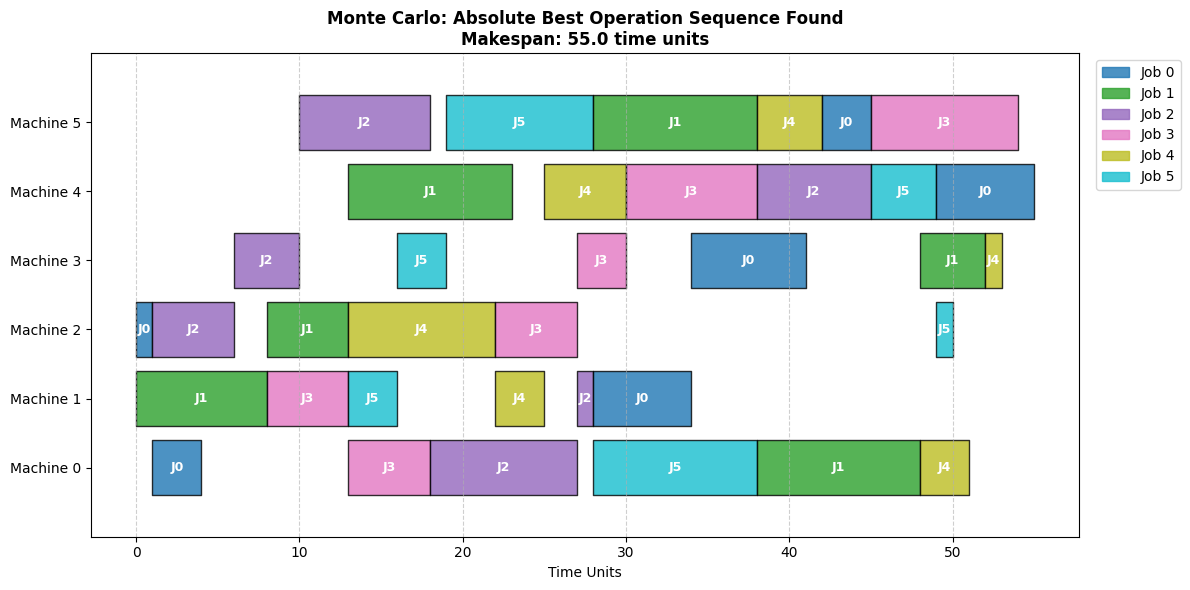

(array([58., 58., 57., 58., 57., 55., 57., 58., 58., 58.]),
 array([ 8,  1, 20, 16, 33,  2, 10, 25, 11, 21, 12, 30, 14, 17, 27, 18, 13,
        35,  7, 22,  4, 28, 26, 19,  5, 34, 15,  0, 32,  6, 23,  3,  9, 24,
        29, 31]),
 55.0)

In [ ]:
run_monte_carlo(num_runs=10)

In [ ]:
run_monte_carlo(num_runs=10)